In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install torch
!pip install torchvision
!pip install xgboost
!pip install dice_ml
!pip install lime
!pip install shap

In [12]:
import dice_ml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lime
import shap
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import partial_dependence, permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from xgboost import XGBClassifier

In [13]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=50), 
    "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# Loan approval system

Dataset source: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [14]:
data1 = pd.read_csv("./Datasets/LoanApproval.csv")
data1

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [15]:
data1.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [16]:
data1.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [17]:
#X = data1.drop(columns=['loan_status', 'loan_percent_income', 'previous_loan_defaults_on_file'])
X = data1.drop(columns=['loan_status'])
y = data1['loan_status']

In [18]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train_data1, X_test_data1, y_train_data1, y_test_data1 = train_test_split(X, y, test_size=0.2, random_state=42)
feature_names = numerical_cols + categorical_cols

In [19]:
preprocessor_data1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ]
)

X_train_processed_data1 = preprocessor_data1.fit_transform(X_train_data1)
X_test_processed_data1 = preprocessor_data1.transform(X_test_data1)

In [20]:
feature_names = numerical_cols + list(preprocessor_data1.named_transformers_['cat'].get_feature_names_out(categorical_cols))
X_train_final_data1 = pd.DataFrame(X_train_processed_data1, columns=feature_names, index=X_train_data1.index)
X_test_final_data1 = pd.DataFrame(X_test_processed_data1, columns=feature_names, index=X_test_data1.index)

In [21]:
trained_models_data1 = {}

for name in models:
    model  = models[name].fit(X_train_final_data1, y_train_data1)
    trained_models_data1[name] = model

/home/alexis/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [14:48:19] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [22]:
X_train_final_data1.columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'person_gender_female', 'person_gender_male',
       'person_education_Associate', 'person_education_Bachelor',
       'person_education_Doctorate', 'person_education_High School',
       'person_education_Master', 'person_home_ownership_MORTGAGE',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION',
       'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT',
       'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE',
       'previous_loan_defaults_on_file_No',
       'previous_loan_defaults_on_file_Yes'],
      dtype='object')

In [23]:
size = len(X_train_final_data1.columns)
size

27

## Global explanation

### Permutation importance

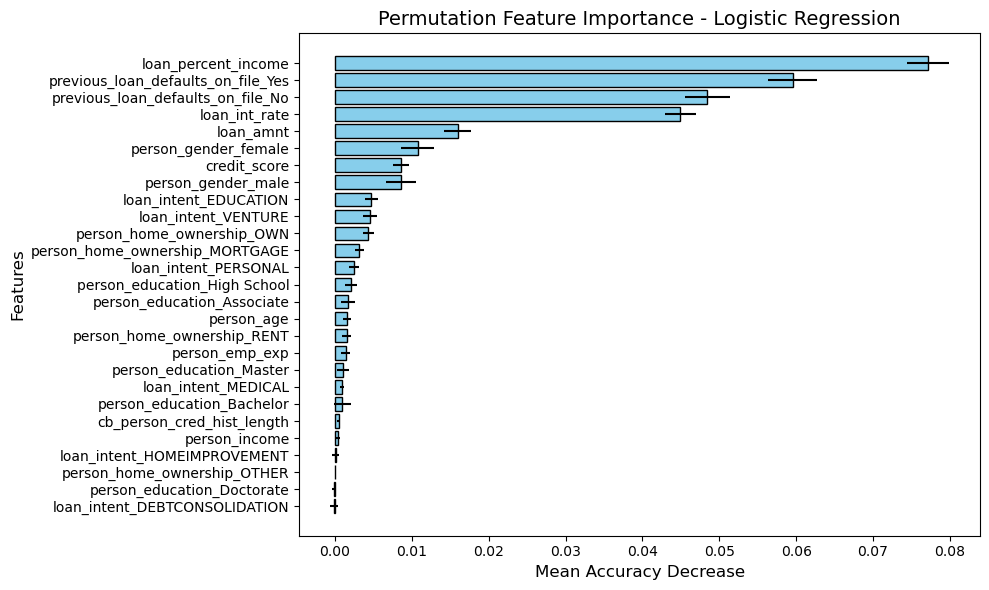

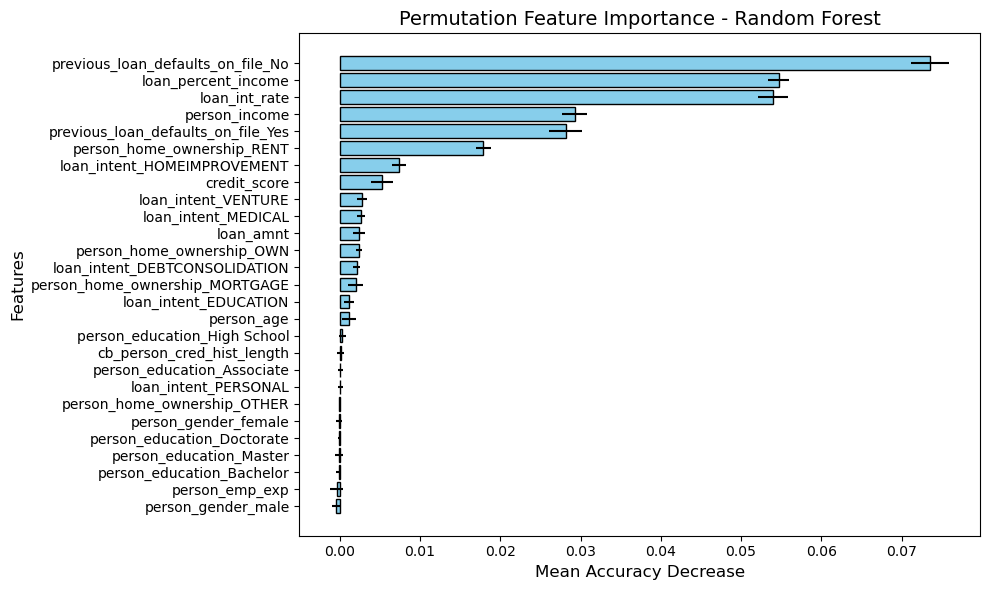

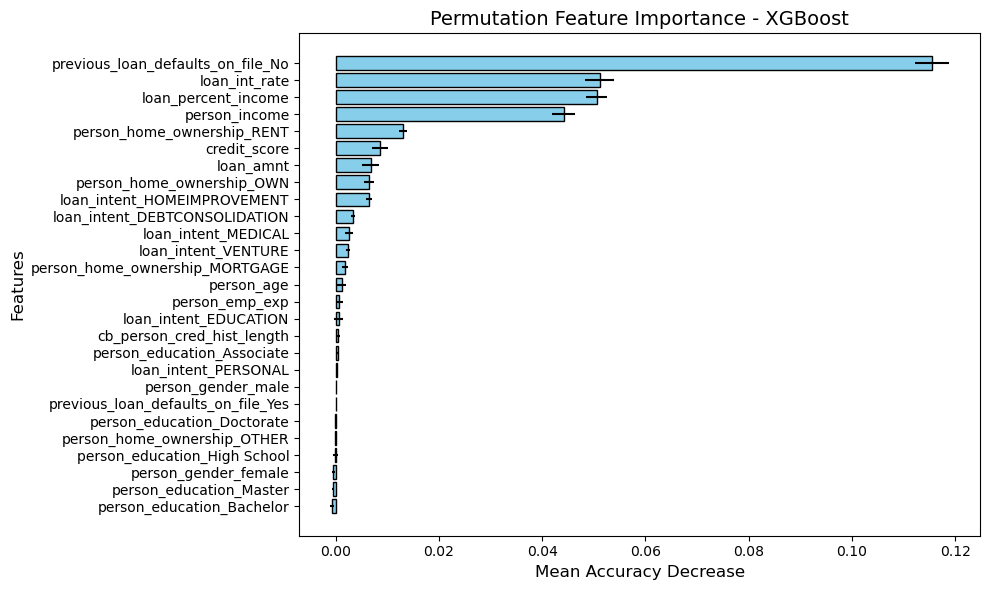

In [24]:
exp_PI_data1 = {}

for name in models:
    trained_model = trained_models_data1[name]
    result = permutation_importance(trained_model, X_test_final_data1, y_test_data1, n_repeats=10, random_state=42)
    sorted_idx = result.importances_mean.argsort()
    feature_names = X_test_final_data1.columns[sorted_idx]
    means = result.importances_mean[sorted_idx]
    stds = result.importances_std[sorted_idx]
        
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(feature_names, means, xerr=stds, align='center', color='skyblue', edgecolor='black')
    ax.set_title(f"Permutation Feature Importance - {name}", fontsize=14)
    ax.set_xlabel("Mean Accuracy Decrease", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    exp_PI_data1[name] = result

Signal-to-noise Ratio: Mean divided by standard deviation
$$
SNR(X)=\frac{\Bbb E[X]}{\sqrt{V[X]}}
$$

In [ ]:
def explanation_per_max_mean(exp_data, model_name, features, number_of_features):
    result = exp_data[model_name]
    sorted_idx = result.importances_mean.argsort()
    feature_names = features[sorted_idx]
    means = result.importances_mean[sorted_idx]
    
    top_features = feature_names[-number_of_features:]
    top_means = means[-number_of_features:]
    
    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_features, top_means, align='center', color='lightgreen', edgecolor='black')
    ax.set_title(f"Top {number_of_features} Features by Mean Importance - {model_name}", fontsize=14)
    ax.set_xlabel("Mean Accuracy Decrease", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return top_features, zip(top_features, top_means)

def explanation_per_SNR(exp_data, model_name, features, number_of_features):#Signal to Noise Ratio
    result = exp_data[model_name]
    result_snr = result.importances_mean / (result.importances_std + 1e-15)  # Adding a small value to avoid division by zero
    sorted_idx = result_snr.argsort()
    feature_names = features[sorted_idx]
    result_snr = result_snr[sorted_idx]
    
    top_features = feature_names[-number_of_features:]
    top_snr = result_snr[-number_of_features:]
    
    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_features, top_snr, align='center', color='lightgreen', edgecolor='black')
    ax.set_title(f"Top {number_of_features} Features by SNR - {model_name}", fontsize=14)
    ax.set_xlabel("Signal to Noise Ratio", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    return top_features, zip(top_features, top_snr)

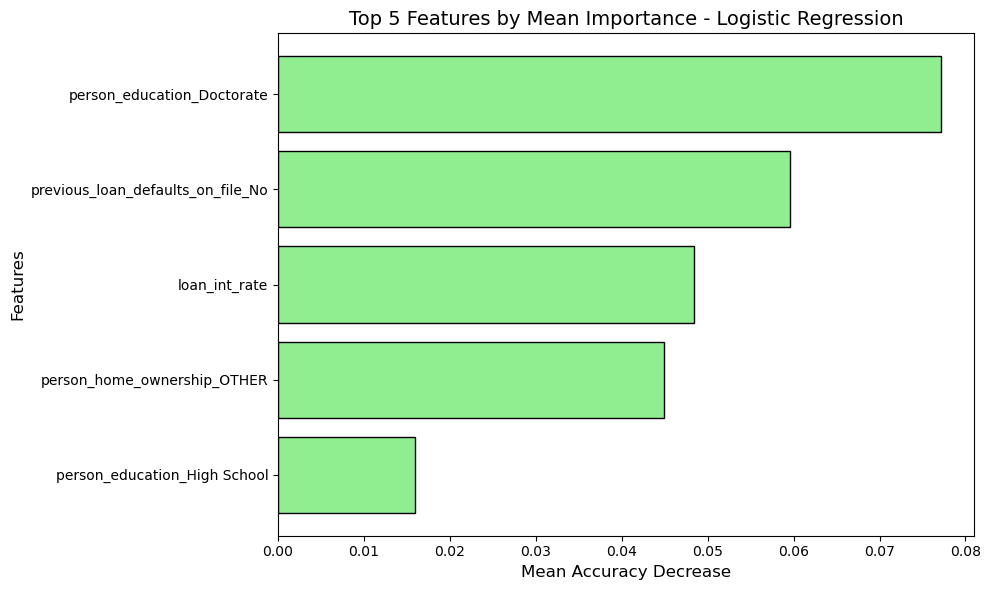

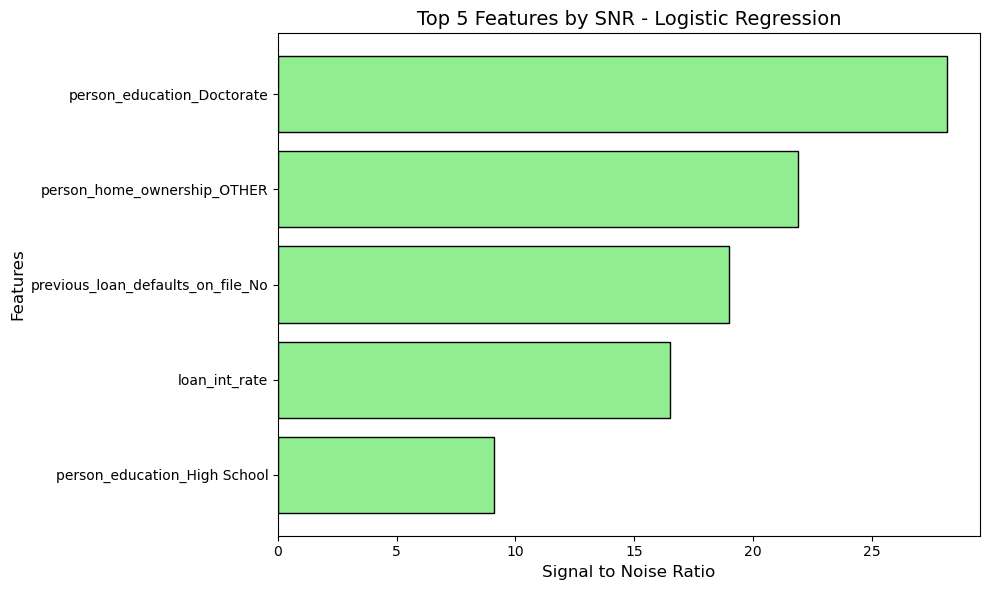

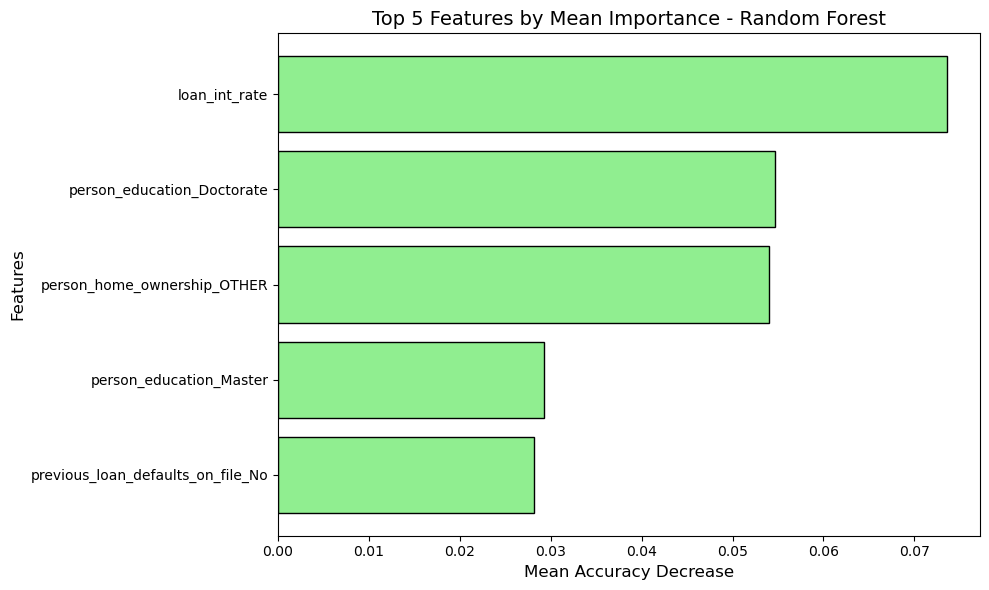

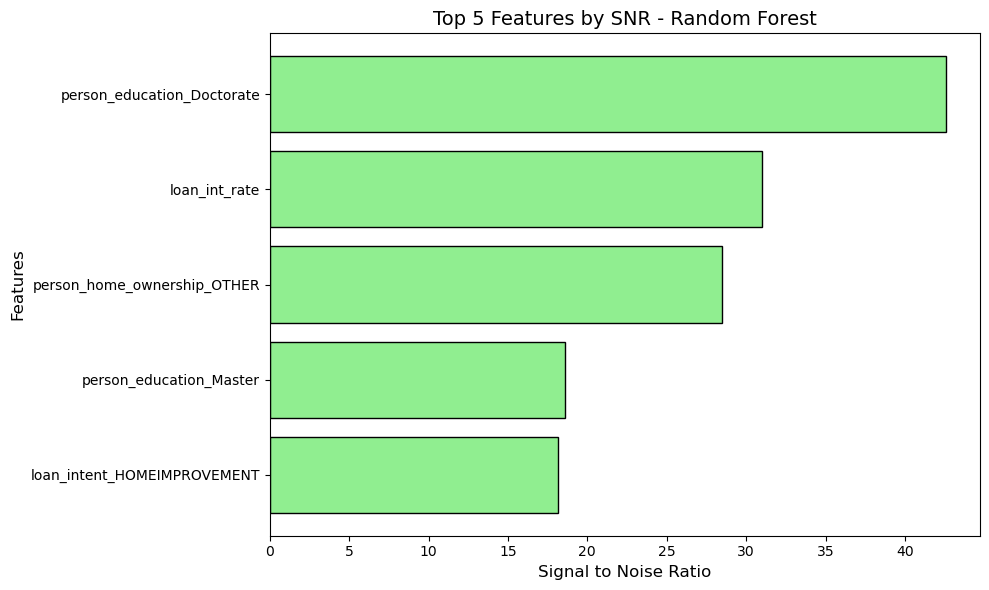

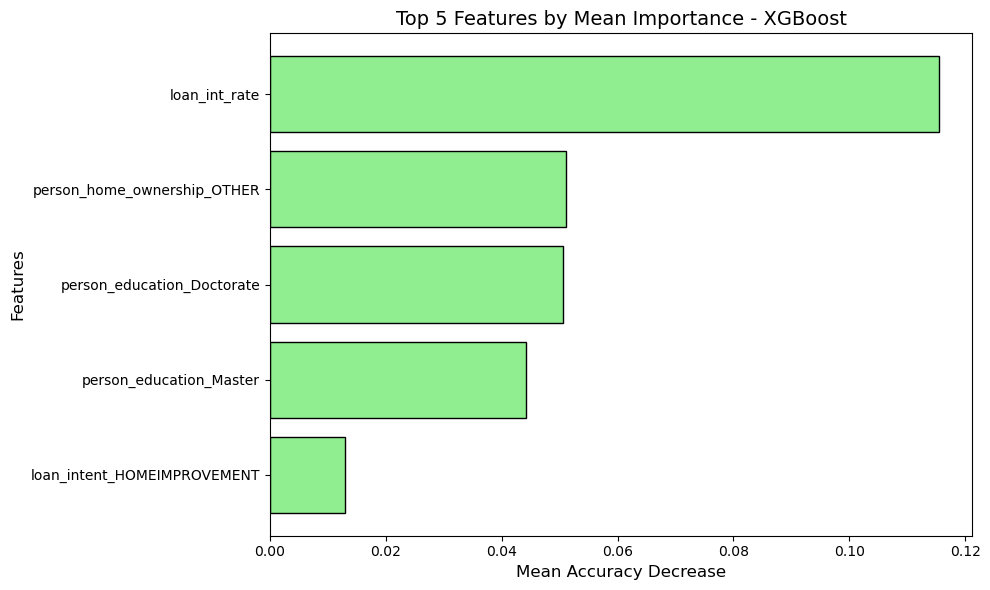

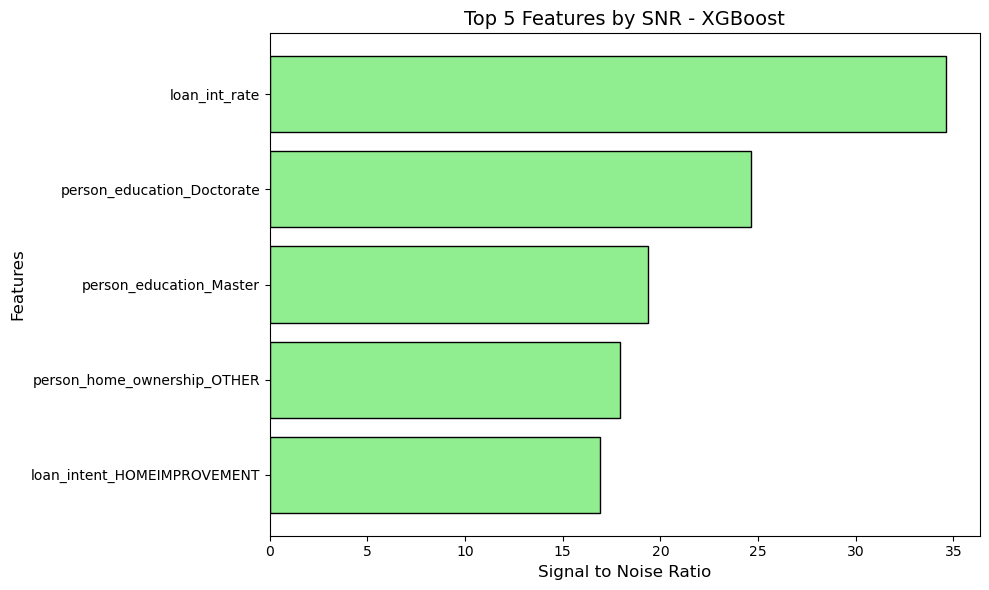

In [26]:
for model_name, result in exp_PI_data1.items():
    explanation_per_max_mean(exp_PI_data1, model_name, feature_names, 5)
    explanation_per_SNR(exp_PI_data1, model_name, feature_names, 5)

### Global SHAP

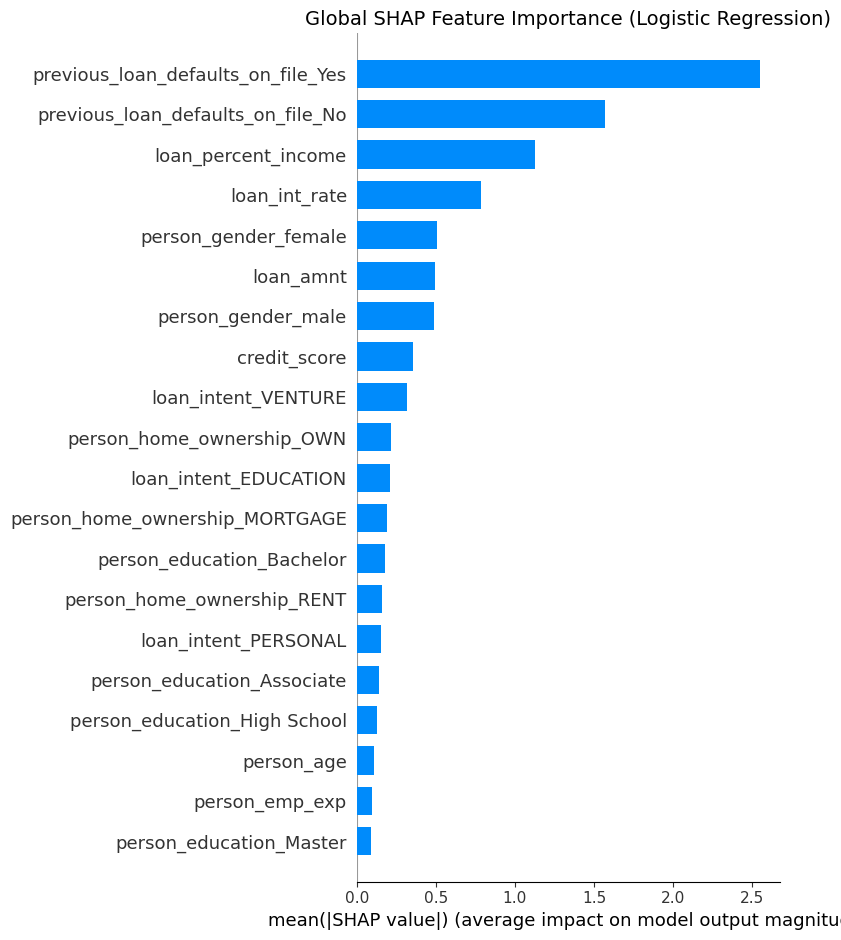

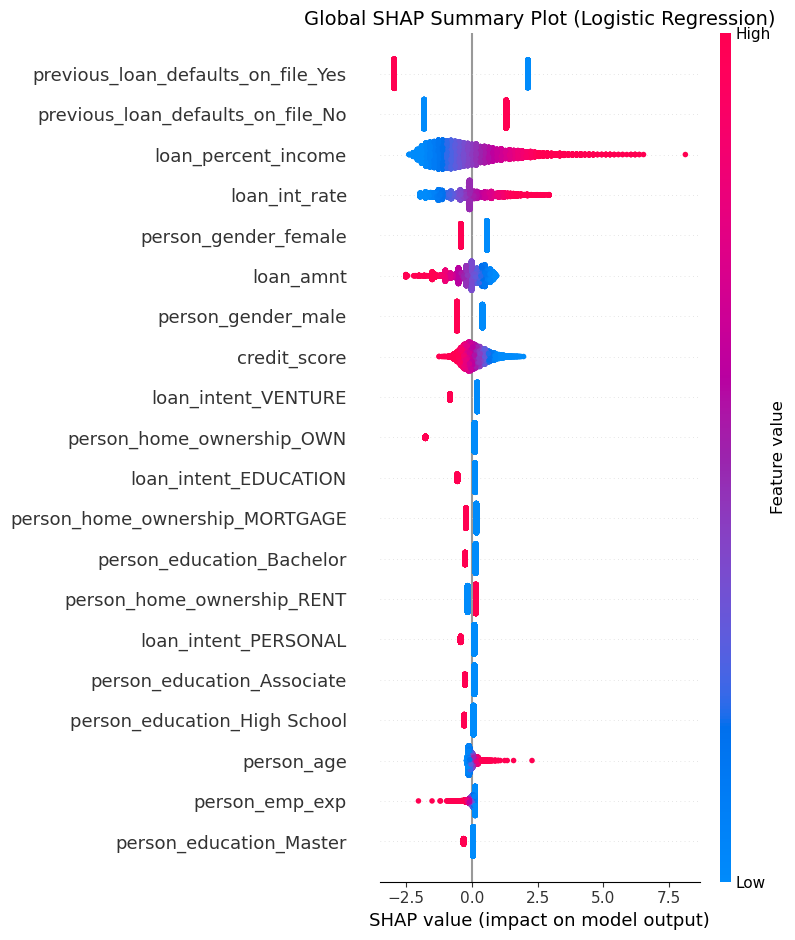

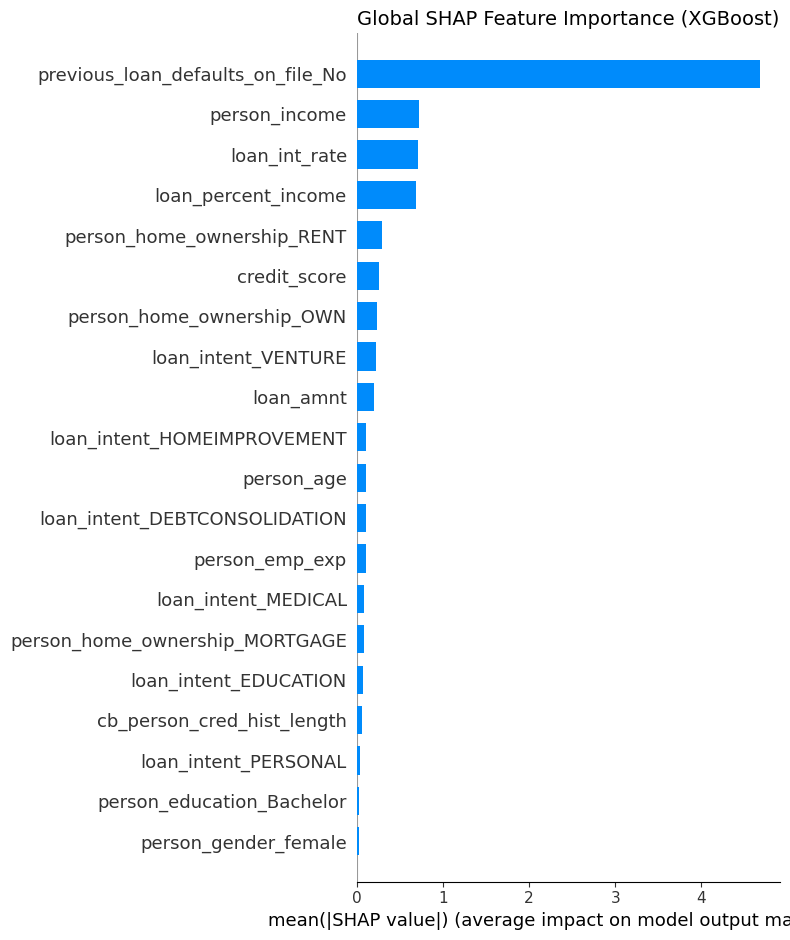

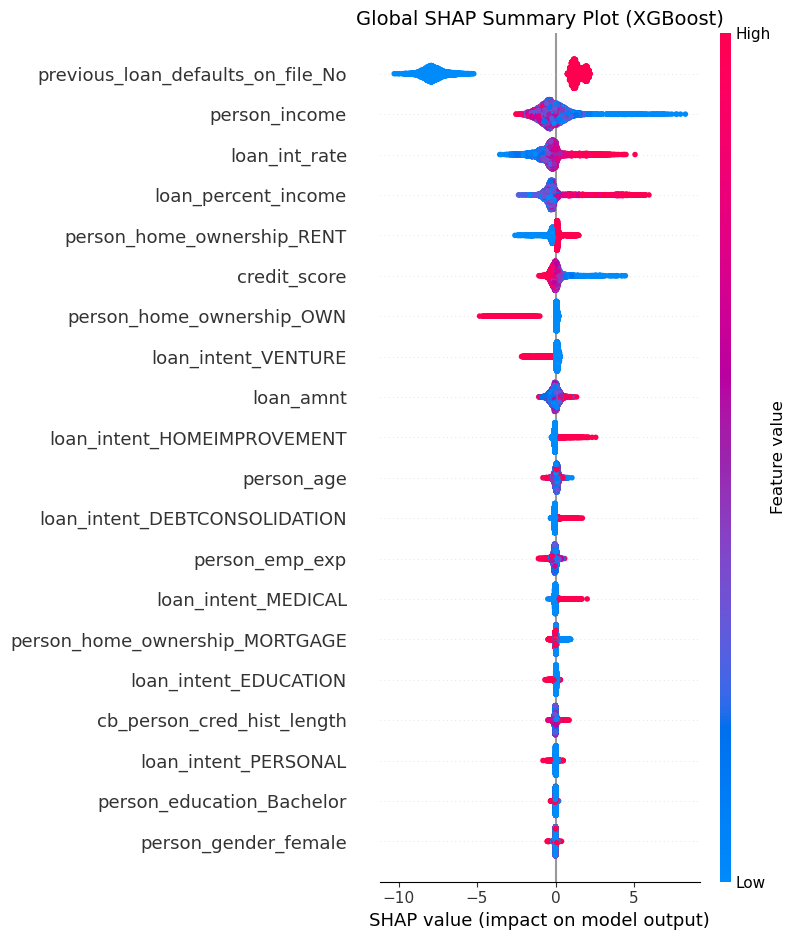

In [27]:
exp_shap_data1 = {}

for name in models:
    model = trained_models_data1[name]
    if name == "Logistic Regression":
        explainer = shap.LinearExplainer(model, X_train_final_data1)
    elif name == "XGBoost":
        explainer = shap.TreeExplainer(model)
    else: continue
    shap_values = explainer.shap_values(X_test_final_data1)
        
    plt.figure(figsize=(10, 6))
    plt.title(f"Global SHAP Feature Importance ({name})", fontsize=14)
    shap.summary_plot(shap_values, X_test_final_data1, plot_type="bar", show=False)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.title(f"Global SHAP Summary Plot ({name})", fontsize=14)
    shap.summary_plot(shap_values, X_test_final_data1, show=False)
    plt.show()

    exp_shap_data1[name] = shap_values

In [ ]:
def explanation_per_shap_values(exp_data, ordered_features, model_name, number_of_features):
    shap_values = exp_data[model_name]
    
    mean_abs_shap_values = np.mean(np.abs(shap_values), axis=0)
    sorted_idx = np.argsort(mean_abs_shap_values)
    
    top_features = ordered_features[sorted_idx][-number_of_features:]
    top_shap_values = mean_abs_shap_values[sorted_idx][-number_of_features:]
    
    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_features, top_shap_values, align='center', color='lightcoral', edgecolor='black')
    ax.set_title(f"Top {number_of_features} Features by Mean Absolute SHAP Values - {model_name}", fontsize=14)
    ax.set_xlabel("Mean Absolute SHAP Value", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    return top_features, zip(top_features, top_shap_values)

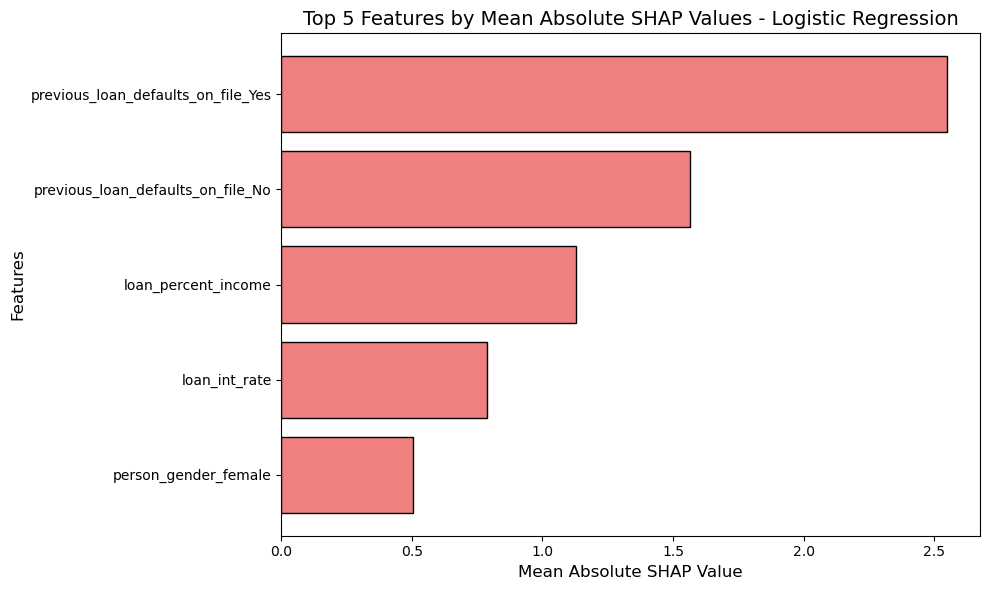

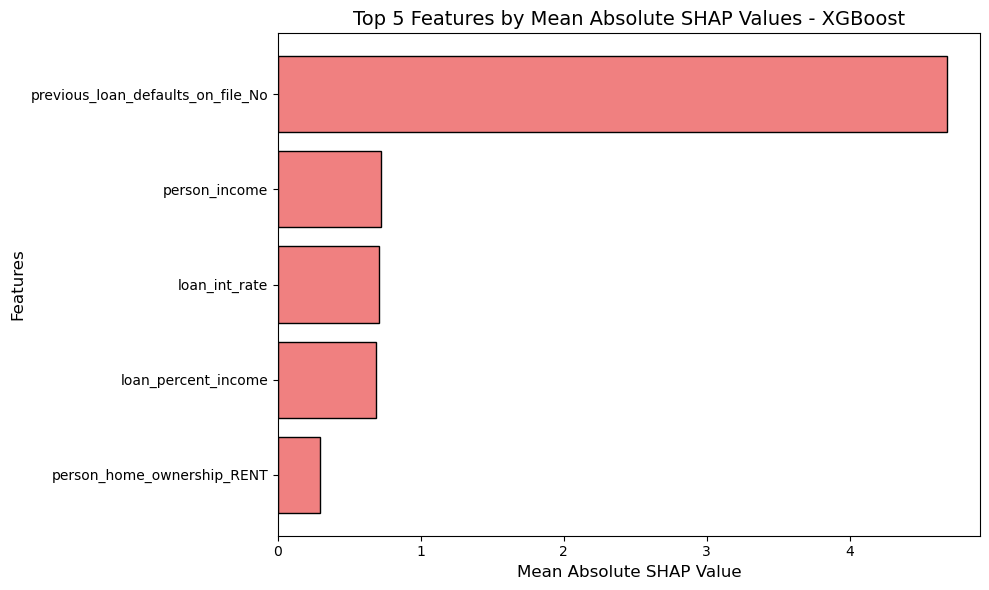

In [29]:
for model_name, result in exp_shap_data1.items():
    explanation_per_shap_values(exp_shap_data1, X_test_final_data1.columns, model_name, 5)

### PDP

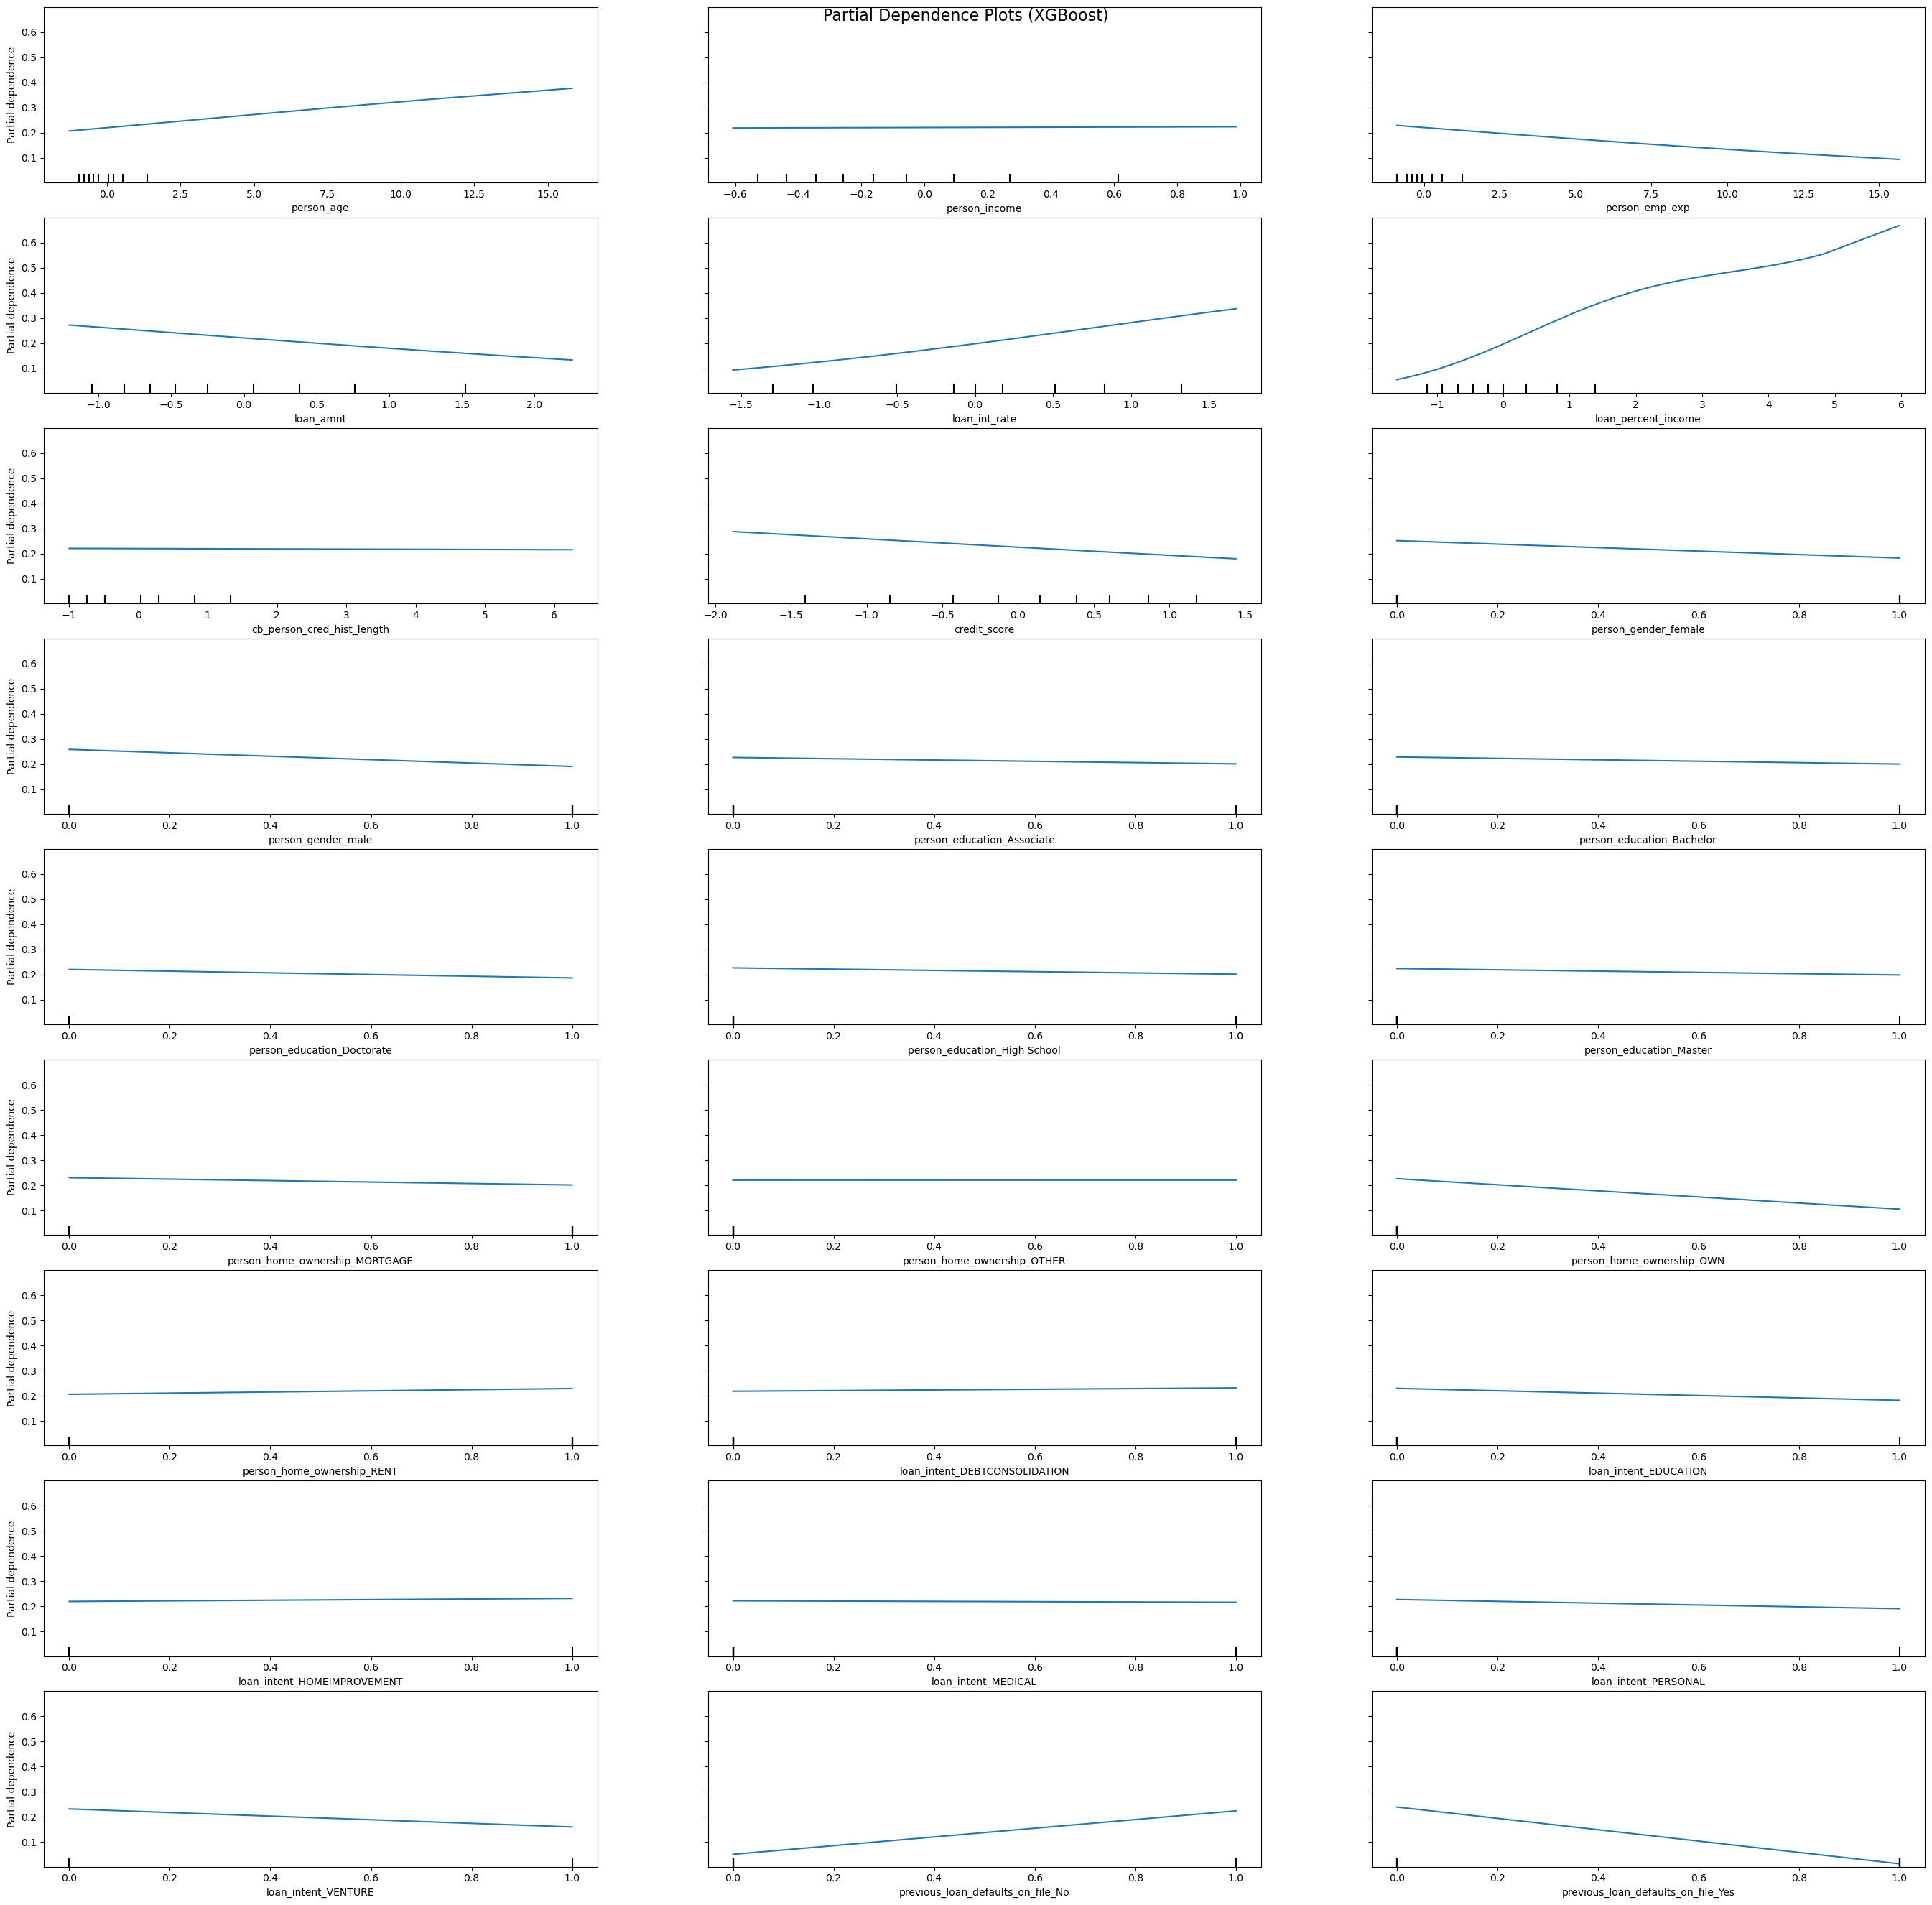

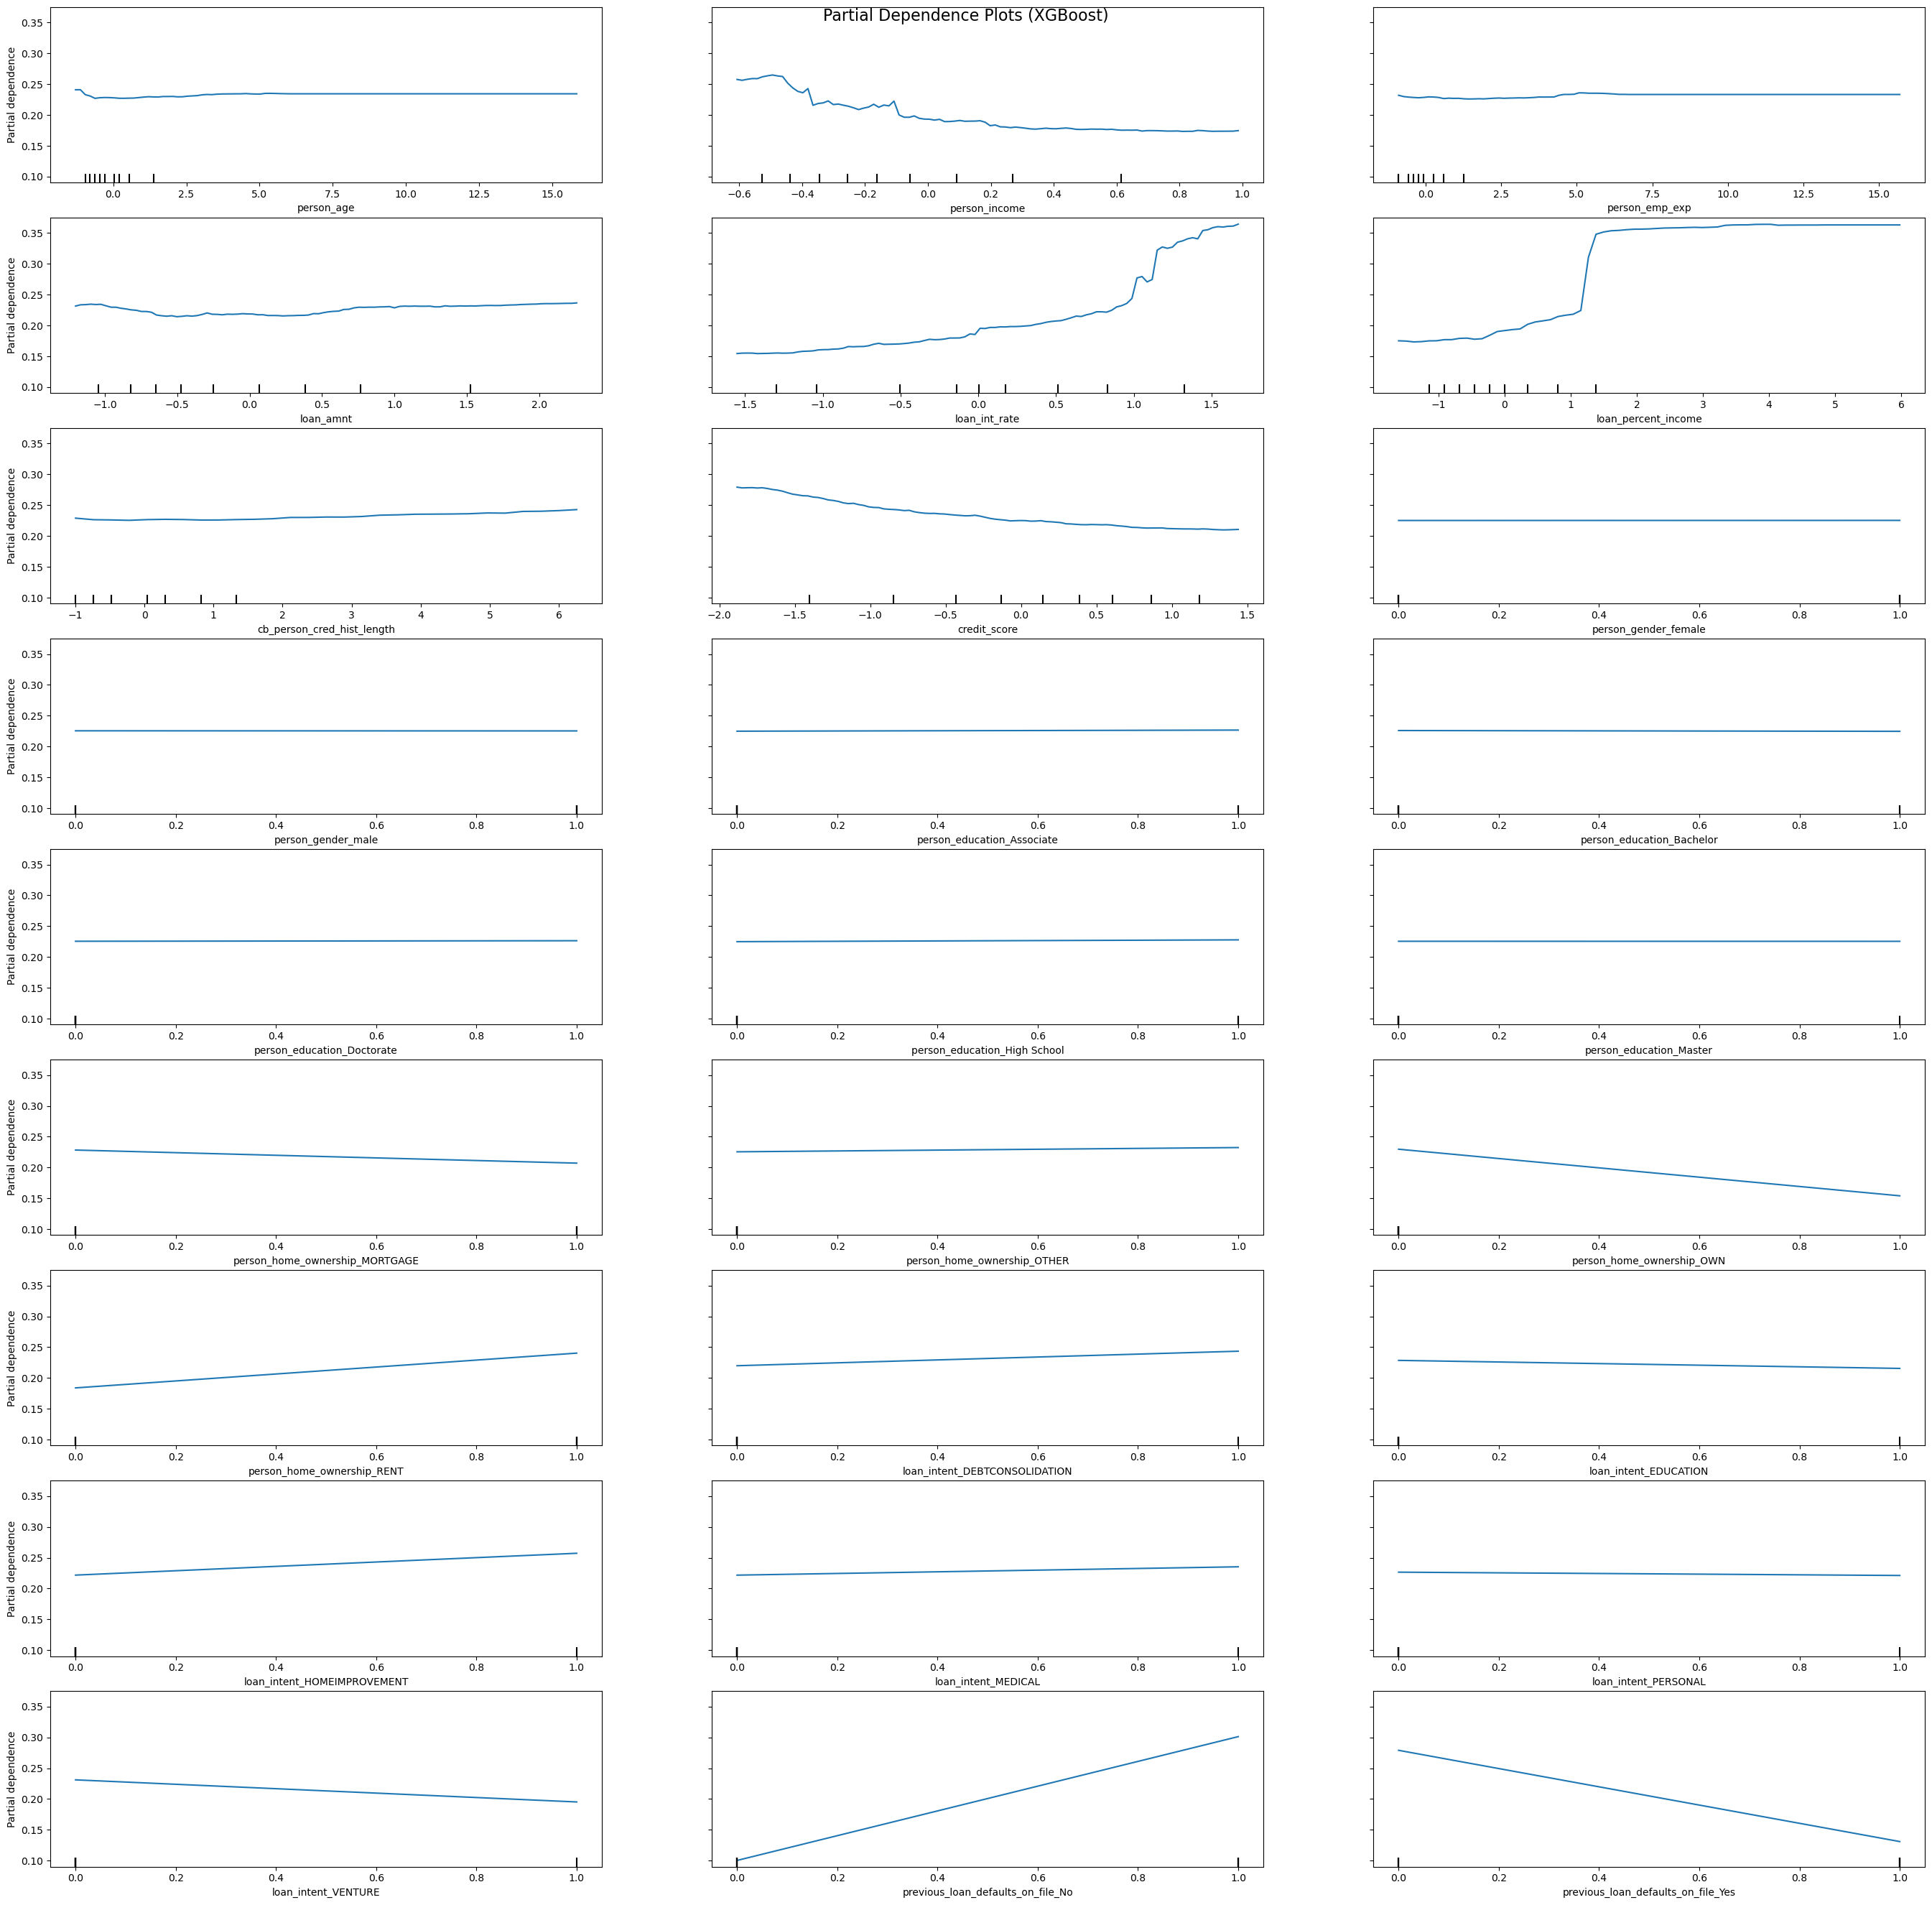

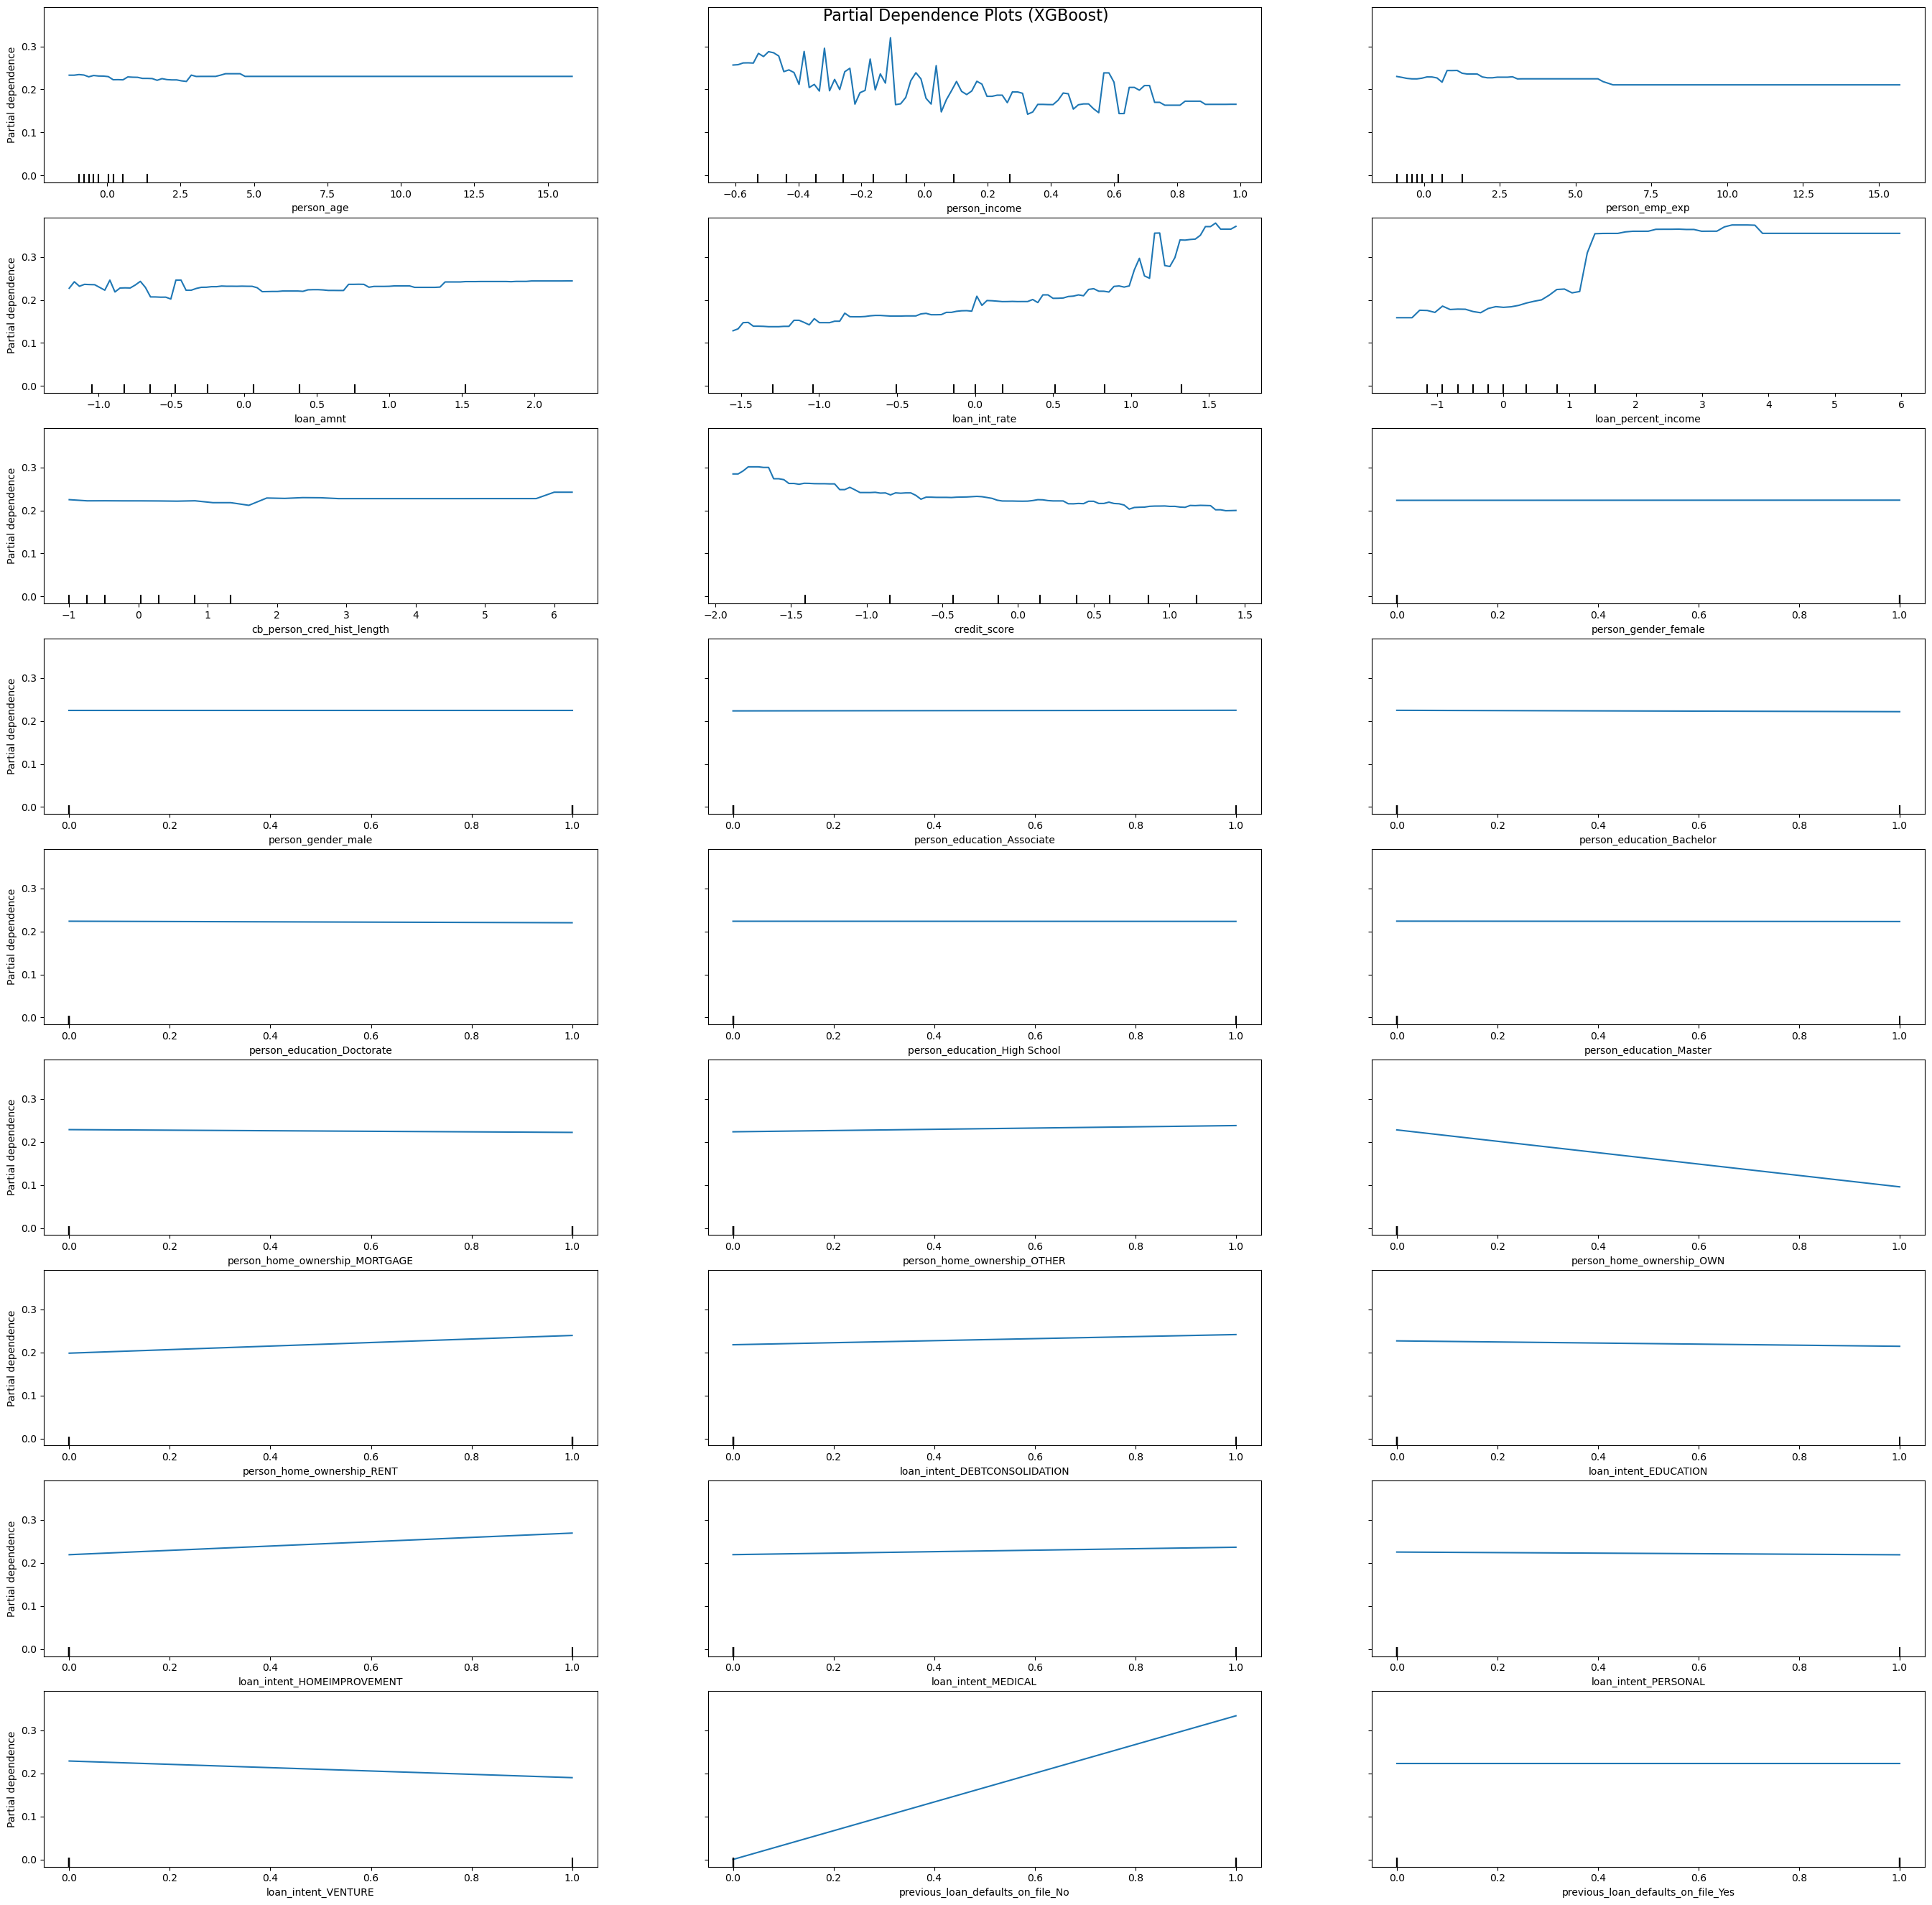

In [30]:
exp_pdp_ice_data1 = {}

for name in models:
    model = trained_models_data1[name]
    features_to_plot = X_test_final_data1.columns
    fig, ax = plt.subplots(figsize=(size, size))
    display = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=X_test_final_data1,
        features=features_to_plot,
        kind="average",       
        subsample=50,
        random_state=42,
        ax=ax
    )
    fig.suptitle(f"Partial Dependence Plots ({model_name})", fontsize=16)
    fig.tight_layout()
    plt.show()

    exp_pdp_ice_data1[name] = display

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_pdp_metrics(display_obj):
    signals = []
    snrs = []
    
    for res in display_obj.pd_results:
        y = res['average'][0] 
        
        S = np.max(y) - np.min(y)
        
        dy = np.gradient(y)
        d2y = np.gradient(dy)
        
        J = np.sqrt(np.mean(d2y**2))
        
        SNR = S / (J + 1e-15)
        
        signals.append(S)
        snrs.append(SNR)
        
    return np.array(signals), np.array(snrs)

def explanation_pdp_max_signal(exp_data, model_name, features, number_of_features):
    display = exp_data[model_name]
    signals, _ = get_pdp_metrics(display)
    
    sorted_idx = signals.argsort()
    feature_names = features[sorted_idx]
    top_signals = signals[sorted_idx]
    
    top_features = feature_names[-number_of_features:]
    top_vals = top_signals[-number_of_features:]
    
    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_features, top_vals, align='center', color='lightcoral', edgecolor='black')
    ax.set_title(f"Top {number_of_features} Features by PDP Signal (Amplitude) - {model_name}", fontsize=14)
    ax.set_xlabel("Signal (Max - Min PDP Value)", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    return top_features, zip(top_features, top_vals)

def explanation_pdp_SNR(exp_data, model_name, features, number_of_features):
    display = exp_data[model_name]
    _, snrs = get_pdp_metrics(display)
    
    sorted_idx = snrs.argsort()
    feature_names = features[sorted_idx]
    top_snrs = snrs[sorted_idx]
    
    top_features = feature_names[-number_of_features:]
    top_vals = top_snrs[-number_of_features:]
    
    _, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_features, top_vals, align='center', color='mediumpurple', edgecolor='black')
    ax.set_title(f"Top {number_of_features} Features by PDP SNR - {model_name}", fontsize=14)
    ax.set_xlabel("Signal to Noise Ratio (Amplitude / Structural Jerk)", fontsize=12)
    ax.set_ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    return top_features, zip(top_features, top_vals)

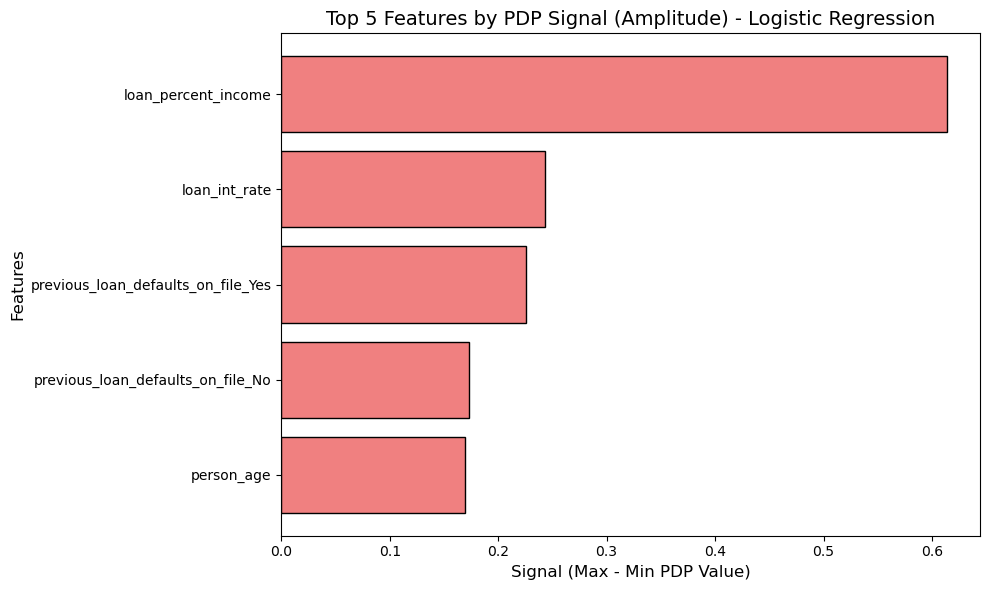

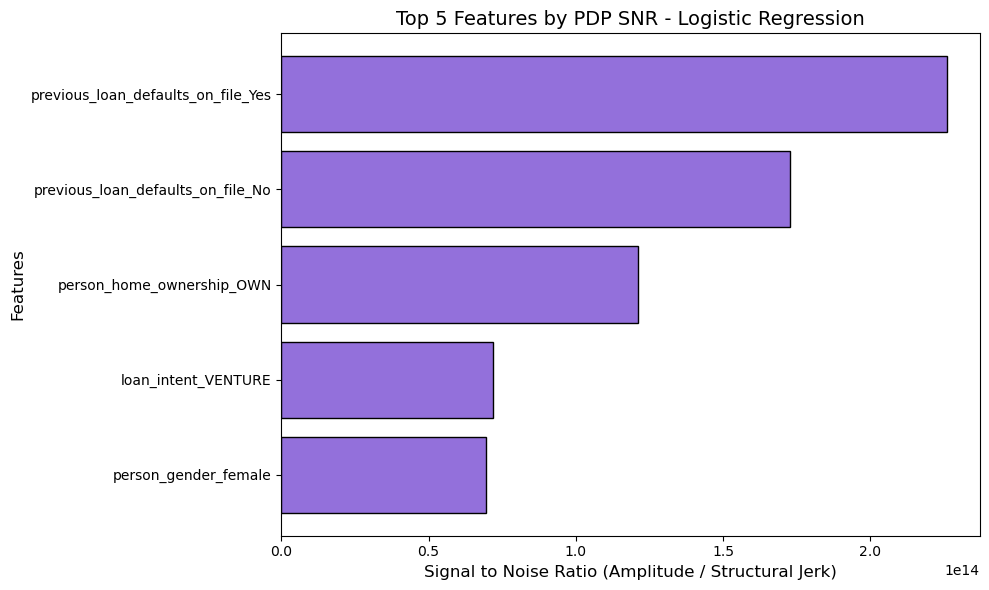

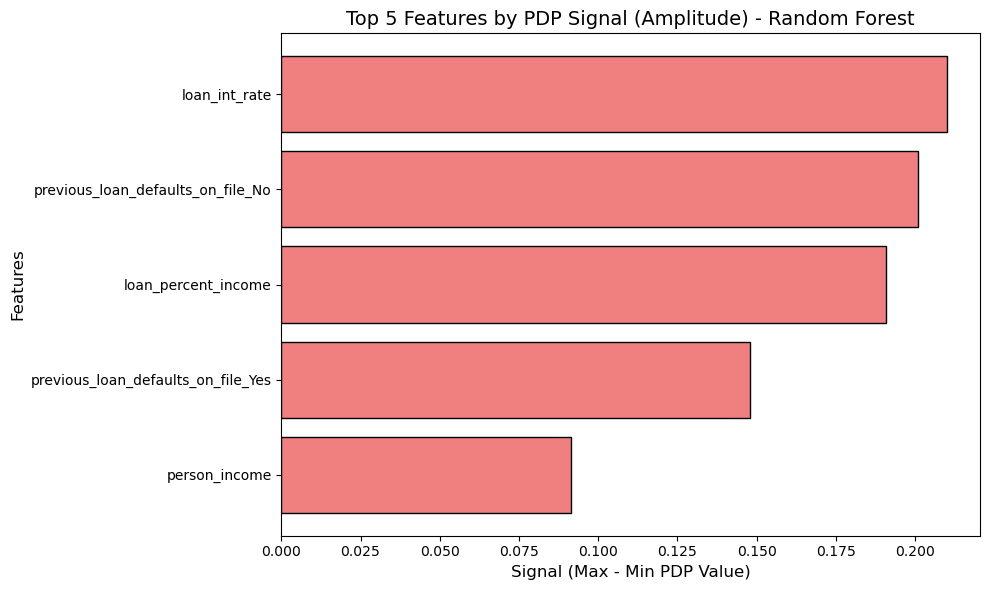

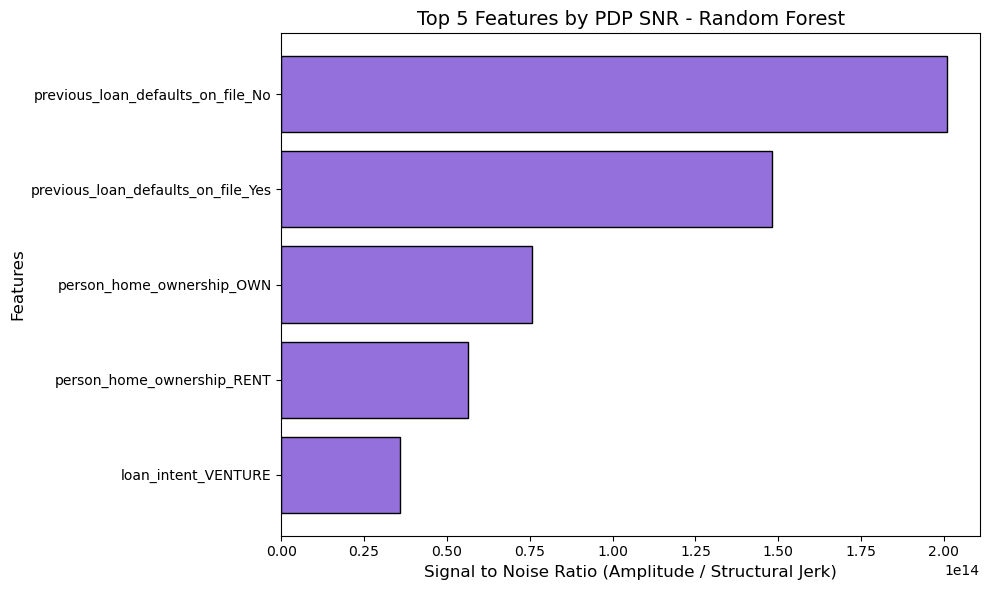

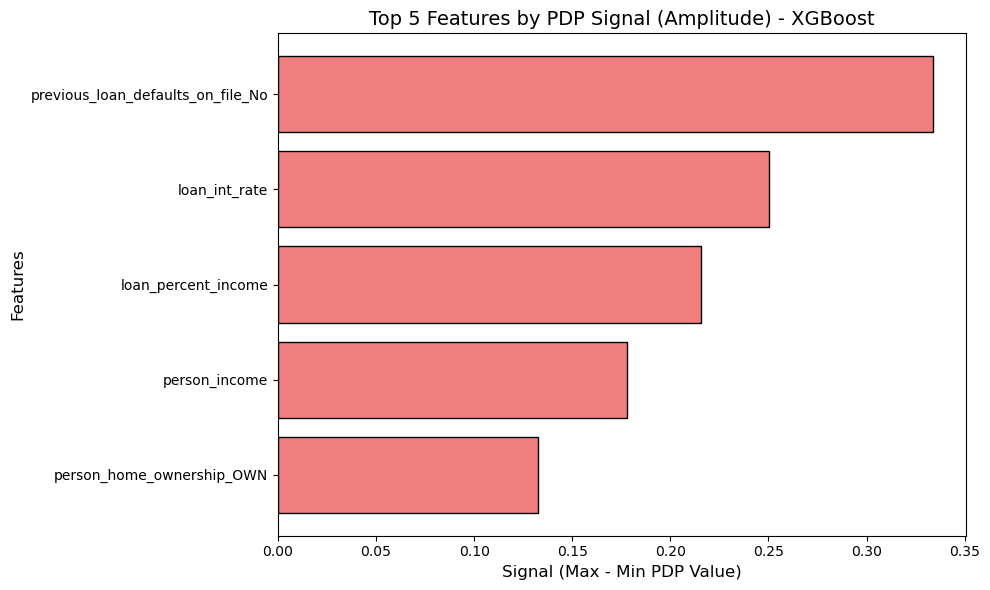

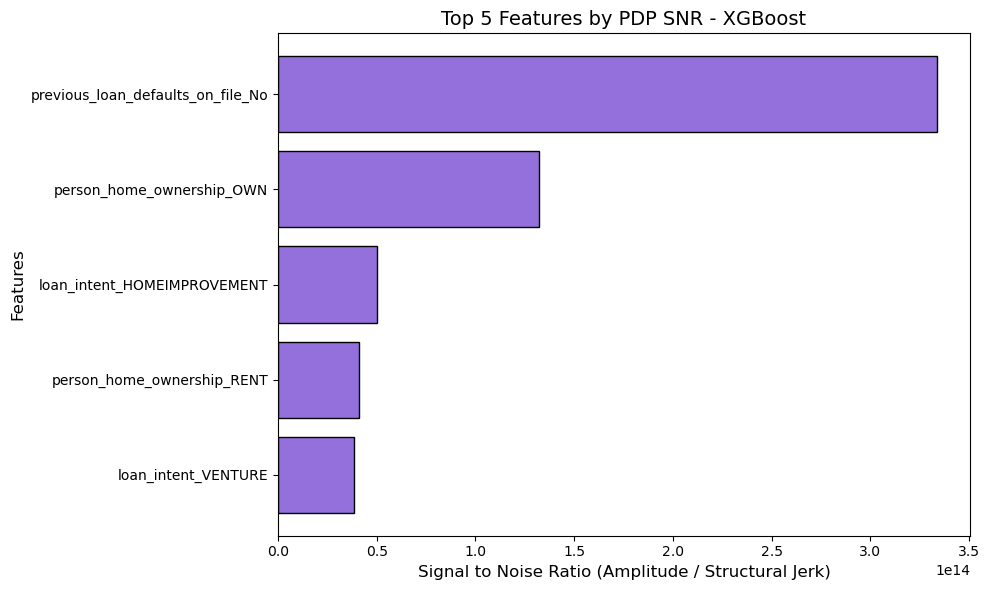

In [33]:
features_to_plot = X_test_final_data1.columns 

for model_name in models:
    explanation_pdp_max_signal(exp_pdp_ice_data1, model_name, features_to_plot, 5)
    explanation_pdp_SNR(exp_pdp_ice_data1, model_name, features_to_plot, 5)

## Local explanation

In [ ]:
instance = X_test_final_data1.iloc[0]
instance_values = instance.values
instance_values

dice_instance_query = X_test_final_data1.iloc[[0]]
dice_instance_query

### Local explanation with LIME

In [ ]:
for name in models:
    model = trained_models_data1[name]
    
    train_data = X_train_final_data1.values
    feature_names = X_train_final_data1.columns.tolist()
    class_names = [str(c) for c in y_train_data1.unique()]
    
    explainer = lime.lime_tabular.LimeTabularExplainer(
        training_data=train_data,
        feature_names=feature_names,
        class_names=class_names,
        mode='classification'
    )
    
    
    exp = explainer.explain_instance(
        data_row=instance_values,
        predict_fn=model.predict_proba
    )
    
    print(f"\n{'-'*40}\nLIME Explanation for: {name}")
    print("Instance values:\n", instance)
    
    fig = exp.as_pyplot_figure()
    plt.title(f"LIME Local Explanation ({name})", fontsize=14)
    plt.tight_layout()
    plt.show()

### Local explanation with DiCE

In [ ]:
for name in models:
    model = trained_models_data1[name]    
    
    df_train = X_train_final_data1.copy()
    df_train['target'] = y_train_data1.values  # Dùng .values để tránh lỗi lệch index
    
    dice_data = dice_ml.Data(
        dataframe=df_train,
        continuous_features=X_train_final_data1.columns.tolist(),
        outcome_name='target'
    )
    
    dice_model = dice_ml.Model(model=model, backend="sklearn")
    explainer_dice = dice_ml.Dice(dice_data, dice_model, method="random")
    
    print(f"\n{'-'*40}\nDiCE Explanation for: {name}")
    print("Query instance:\n", query_instance)
        
    try:
        dice_exp = explainer_dice.generate_counterfactuals(
            query_instance, 
            total_CFs=3,
            desired_class="opposite"
        )
        dice_exp.visualize_as_dataframe(show_only_changes=True)
    except Exception as e:
        print(f"No available explanation. Error: {e}")

### ICE

In [ ]:
exp_ice_data1 = {}

for name in models:
    model = trained_models_data1[name]
    features_to_plot = X_test_final_data1.columns
    fig, ax = plt.subplots(figsize=(size, size))
    display = PartialDependenceDisplay.from_estimator(
        estimator=model,
        X=instance,
        features=features_to_plot,
        kind="individual",       
        subsample=50,
        random_state=42,
        ax=ax
    )
    fig.suptitle(f"Individual Conditional Expectation Plots ({model_name})", fontsize=16)
    fig.tight_layout()
    plt.show()

    exp_ice_data1[name] = display